# Раздел 1: Data Acquisition & Risk Filtering (Absolute Momentum)

В этом блоке мы выделяем активы, которые показывают сильный импульс роста, но при этом сохраняют историческую «просадку» в пределах 5%, что является критическим фильтром для нашего гибридного портфеля.

✅ Период анализа: 2024-01-01 — 2026-03-27
🎯 Лимит риска: Max Drawdown > -5.00%
📊 Прошли фильтр: SGD, EUR, CHF, PLN, NOK



Ticker,CAGR (%),Downside Vol (%),Max Drawdown (%),Sortino
SGD,2.00%,1.19%,-1.87%,1.69
ILS,5.38%,3.60%,-5.17%,1.50
EUR,2.58%,2.37%,-3.24%,1.09
SEK,3.38%,4.23%,-5.26%,0.80
CHF,2.92%,3.73%,-4.69%,0.78
PLN,3.18%,4.10%,-4.64%,0.78
NOK,2.73%,5.16%,-4.85%,0.53
COP,3.05%,7.04%,-13.75%,0.43
AUD,1.51%,4.56%,-10.37%,0.33
NZD,-2.13%,4.39%,-11.21%,-0.49


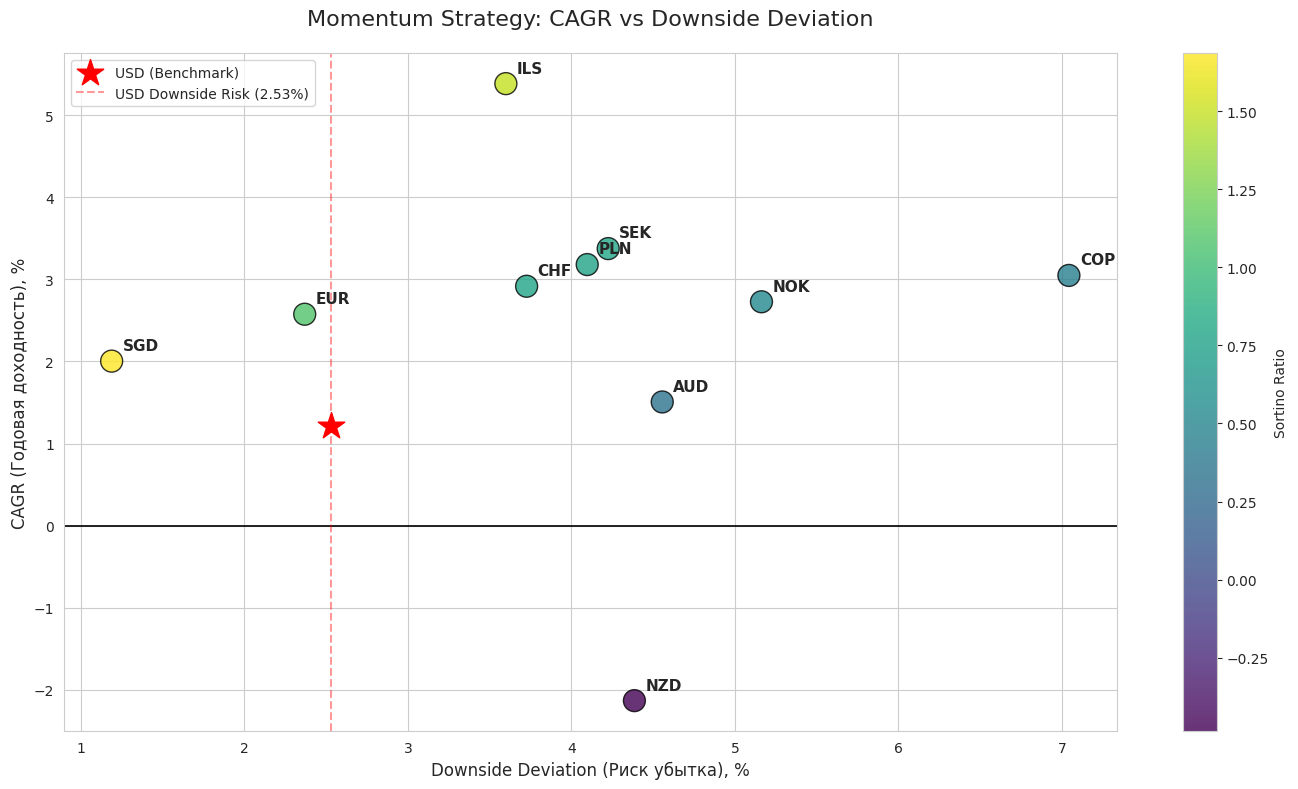

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# --- 1.1. Загрузка и первичная очистка ---
file_path = '/kaggle/input/notebooks/eavprog/abscur2/abscur.csv'
df_raw = pd.read_csv(file_path, parse_dates=['Date']).sort_values('Date').set_index('Date')

# Устанавливаем горизонт: Январь 2024 — Март 2026
start_date = '2024-01-01'
end_date = df_raw.index.max()
df_prices = df_raw.loc[start_date:end_date].copy()
df_prices = df_prices.dropna(axis=1).ffill().bfill()
df_returns = np.log(df_prices / df_prices.shift(1)).dropna()

# --- 1.2. Определение пула активов ---
target_tickers = ['SGD', 'EUR', 'COP', 'PLN', 'CHF', 'ILS', 'NOK', 'SEK', 'AUD', 'NZD']
benchmark_ticker = 'USD'

available_tickers = [t for t in target_tickers if t in df_returns.columns]

# --- 1.3. Расчет риск-метрик в процентах ---
def get_metrics_pct(returns_series):
    """Расчет метрик в процентном выражении"""
    # CAGR в %
    cagr = (returns_series.mean() * 252) * 100
    
    # Downside Deviation (только отрицательные доходности) в %
    downside_returns = returns_series[returns_series < 0]
    downside_vol = (downside_returns.std() * np.sqrt(252)) * 100
    
    # Max Drawdown в %
    cumulative = (1 + returns_series).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    mdd = drawdown.min() * 100
    
    # Sortino Ratio (безразмерный коэффициент)
    sortino = cagr / downside_vol if downside_vol != 0 else 0
    
    return cagr, downside_vol, mdd, sortino

# --- 1.4. Сбор статистики ---
stats = []
for ticker in available_tickers:
    c, dv, mdd, s = get_metrics_pct(df_returns[ticker])
    url = f"https://www.abscur.ru/p/2.html?abs={ticker}"
    link = f'<a href="{url}" target="_blank">{ticker}</a>'
    
    stats.append({
        'Ticker': link,
        'CAGR (%)': c,
        'Downside Vol (%)': dv,
        'Max Drawdown (%)': mdd,
        'Sortino': s
    })

df_stats = pd.DataFrame(stats).sort_values('Sortino', ascending=False)

# Фильтрация по MDD > -5% (строго по ТЗ)
df_filtered = df_stats[df_stats['Max Drawdown (%)'] > -5.0].copy()

# Форматирование таблицы для отображения
df_display = df_stats.copy()
format_cols = ['CAGR (%)', 'Downside Vol (%)', 'Max Drawdown (%)']
for col in format_cols:
    df_display[col] = df_display[col].apply(lambda x: f"{x:.2f}%")
df_display['Sortino'] = df_display['Sortino'].apply(lambda x: round(x, 2))

# --- Контроль и вывод ---
print(f"✅ Период анализа: {start_date} — {end_date.date()}")
print(f"🎯 Лимит риска: Max Drawdown > -5.00%")
print(f"📊 Прошли фильтр: {', '.join([t.split('>')[-2].split('<')[0] for t in df_filtered['Ticker']])}\n")

display(HTML(df_display.to_html(escape=False, index=False)))

# --- 1.5. Визуализация: Доходность vs Downside Risk (в %) ---
plt.figure(figsize=(14, 8), dpi=100)
sns.set_style("whitegrid")

# Точки активов
sc = plt.scatter(df_stats['Downside Vol (%)'], df_stats['CAGR (%)'], 
                c=df_stats['Sortino'], cmap='viridis', s=250, edgecolors='black', alpha=0.8)

# Метрики бенчмарка USD
u_c, u_dv, u_mdd, u_s = get_metrics_pct(df_returns[benchmark_ticker])
plt.scatter(u_dv, u_c, color='red', s=400, marker='*', label='USD (Benchmark)', zorder=5)

# Аннотации тикеров
for i, row in df_stats.iterrows():
    clean_ticker = row['Ticker'].split('>')[-2].split('<')[0]
    plt.annotate(clean_ticker, (row['Downside Vol (%)'], row['CAGR (%)']), 
                 xytext=(8, 8), textcoords='offset points', fontsize=11, fontweight='bold')

plt.colorbar(sc, label='Sortino Ratio')
plt.axhline(0, color='black', lw=1.2, ls='-')
plt.axvline(u_dv, color='red', linestyle='--', alpha=0.4, label=f'USD Downside Risk ({u_dv:.2f}%)')

# Отрисовка зоны фильтра (опционально, если риск по осям позволяет)
plt.title("Momentum Strategy: CAGR vs Downside Deviation", fontsize=16, pad=20)
plt.xlabel("Downside Deviation (Риск убытка), %", fontsize=12)
plt.ylabel("CAGR (Годовая доходность), %", fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

### 🔍 Аналитический отчет: Первичный скрининг и риск-фильтрация (Absolute Momentum)

На основе данных за период с января 2024 по март 2026 года проведен анализ 10 валютных активов. Основной фокус исследования смещен с общей волатильности на **Downside Deviation** (риск убыточных отклонений) и **Max Drawdown** (максимальная историческая просадка) для максимизации **Sortino Ratio**.

**Ключевые выводы по активам:**

* **Эталон эффективности:** [SGD](https://www.abscur.ru/p/2.html?abs=SGD) демонстрирует самый высокий коэффициент Сортино (**1.69**). При CAGR в **2.00%** его риск убытка минимален (Downside Vol **1.19%**, MDD **-1.87%**). Это подтверждает его статус главного защитного актива в гибридном портфеле.
* **Аномалия доходности:** [ILS](https://www.abscur.ru/p/2.html?abs=ILS) показал максимальную доходность (**5.38%**) и высокий Сортино (**1.50**), однако актив **не прошел жесткий фильтр** (MDD **-5.17%** при лимите в -5.00%). Это исключает его из консервативной части, но оставляет в поле зрения для спекулятивных маневров.
* **Ядро импульса (Momentum):** Валюты [EUR](https://www.abscur.ru/p/2.html?abs=EUR), [CHF](https://www.abscur.ru/p/2.html?abs=CHF) и [PLN](https://www.abscur.ru/p/2.html?abs=PLN) успешно преодолели фильтр просадки. Особого внимания заслуживает [PLN](https://www.abscur.ru/p/2.html?abs=PLN), чей CAGR в **3.18%** значительно выше, чем у евро, при сохранении допустимого уровня риска.
* **Зона высокого риска:** [COP](https://www.abscur.ru/p/2.html?abs=COP) и [AUD](https://www.abscur.ru/p/2.html?abs=AUD) показали просадки более **-10%**, что делает их использование в текущей стратегии невозможным без значительного сокращения доли. [NZD](https://www.abscur.ru/p/2.html?abs=NZD) — единственный актив с отрицательной доходностью, что делает его контрпродуктивным для Momentum-стратегии.

**Связь с теорией абсолютных курсов:**
Текущий цикл подтверждает превосходство «тихих гаваней» ([SGD](https://www.abscur.ru/p/2.html?abs=SGD)) и валют с сильным внутренним импульсом ([PLN](https://www.abscur.ru/p/2.html?abs=PLN)) над традиционными сырьевыми валютами в разрезе риск-корректированной доходности.

# Раздел 2: Momentum & Downside Risk Profile

В этом блоке мы переходим от сухих цифр к визуальному анализу. Мы сфокусируемся на **Коэффициенте Сортино** и динамике **Downside Deviation**. Наша задача — увидеть, какие активы стабильно генерируют "положительный" импульс, а какие склонны к резким провалам ниже ватерлинии.

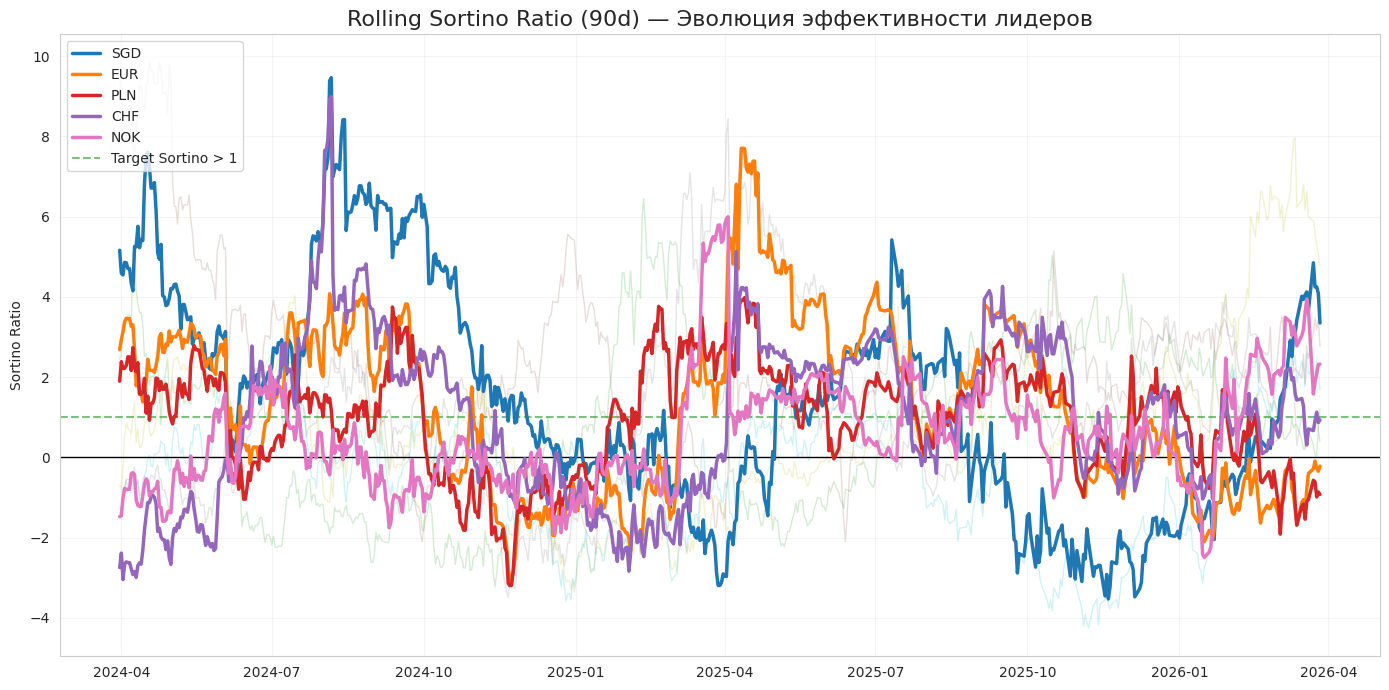

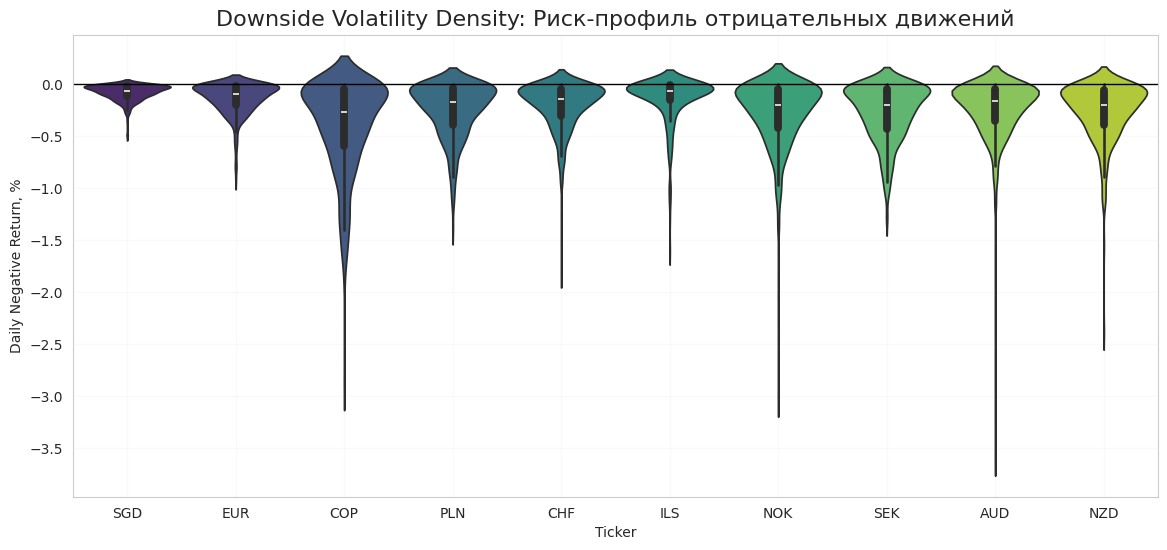

--- Сравнение Downside Risk и Скорректированного Импульса ---


,Downside Vol (%),Skewness,Kurtosis
SGD,1.188471,1.157394,8.908221
EUR,2.369126,0.800573,6.244688
ILS,3.599254,2.117351,25.840472
CHF,3.726154,1.168004,12.087577
PLN,4.096659,0.017788,1.671442
SEK,4.225037,0.175822,1.548815
NZD,4.385191,-0.346357,3.934299
AUD,4.555409,-0.771409,17.535056
NOK,5.162308,-0.548667,4.819447
COP,7.042182,-0.175284,1.772185


In [7]:
# --- 2.0. Определение групп на основе результатов Раздела 1 ---
# Активы, прошедшие риск-фильтр MDD > -5%
selected_tickers = ['SGD', 'EUR', 'CHF', 'PLN', 'NOK']
# Остальные активы для сравнения
other_tickers = [t for t in available_tickers if t not in selected_tickers]

# --- 2.1. Расчет скользящего коэффициента Сортино (Window = 90 дней) ---
window = 90

def rolling_sortino(returns, window=90):
    rolling_mean = returns.rolling(window).mean() * 252
    # Расчет Downside Deviation для окна
    def get_downside(x):
        neg = x[x < 0]
        return neg.std() * np.sqrt(252) if len(neg) > 2 else np.nan
    
    downside_std = returns.rolling(window).apply(get_downside)
    return rolling_mean / downside_std

rolling_s = df_returns[available_tickers].apply(lambda x: rolling_sortino(x, window))

# --- 2.2. Визуализация 1: Динамика эффективности (Rolling Sortino) ---
plt.figure(figsize=(14, 7), dpi=100)
for ticker in available_tickers:
    # Выделяем лидеров ярким цветом и жирной линией
    is_lead = ticker in selected_tickers
    plt.plot(rolling_s.index, rolling_s[ticker], 
             label=ticker if is_lead else None, # В легенду только лидеров, чтобы не загромождать
             alpha=1.0 if is_lead else 0.2, 
             lw=2.5 if is_lead else 1.0,
             zorder=5 if is_lead else 1)

plt.axhline(0, color='black', lw=1)
plt.axhline(1, color='green', ls='--', alpha=0.5, label='Target Sortino > 1')
plt.title(f"Rolling Sortino Ratio ({window}d) — Эволюция эффективности лидеров", fontsize=16)
plt.ylabel("Sortino Ratio")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# --- 2.3. Визуализация 2: Распределение отрицательных доходностей (Violin Plot) ---
downside_data = []
for ticker in available_tickers:
    neg_rets = df_returns[ticker][df_returns[ticker] < 0] * 100
    if not neg_rets.empty:
        temp_df = pd.DataFrame({'Negative Returns (%)': neg_rets, 'Ticker': ticker})
        downside_data.append(temp_df)

df_violin = pd.concat(downside_data)

plt.figure(figsize=(14, 6), dpi=100)
# Исправлено: добавлена привязка hue к Ticker и отключена легенда
sns.violinplot(data=df_violin, x='Ticker', y='Negative Returns (%)', 
               hue='Ticker', palette='viridis', inner="box", legend=False)

plt.title("Downside Volatility Density: Риск-профиль отрицательных движений", fontsize=16)
plt.ylabel("Daily Negative Return, %")
plt.axhline(0, color='black', lw=1)
plt.grid(True, alpha=0.1)
plt.show()

# --- 2.4. Вывод данных для анализа ---
print("--- Сравнение Downside Risk и Скорректированного Импульса ---")
downside_stats = pd.DataFrame(index=available_tickers)
# Рассчитываем Downside Volatility корректно
downside_stats['Downside Vol (%)'] = df_returns.apply(lambda x: (x[x < 0].std() * np.sqrt(252) * 100))
downside_stats['Skewness'] = df_returns.skew() # Отрицательная асимметрия = риск "черных лебедей"
downside_stats['Kurtosis'] = df_returns.kurtosis() # Высокий эксцесс = "толстые хвосты" риска

display(downside_stats.sort_values('Downside Vol (%)'))

### 📊 Анализ риск-профиля: Коэффициент Сортино и асимметрия (Skewness)

Во втором разделе мы декомпозировали риск отобранных активов, сместив акцент с общей волатильности на **Downside Deviation** и форму распределения доходностей.

**Ключевые инсайты:**

* **Качество импульса (Skewness):** Почти все лидеры шорт-листа ([SGD](https://www.abscur.ru/p/2.html?abs=SGD), [EUR](https://www.abscur.ru/p/2.html?abs=EUR), [CHF](https://www.abscur.ru/p/2.html?abs=CHF)) обладают **положительной асимметрией (Skewness > 0)**. Это критически важный сигнал для стратегии Absolute Momentum: их волатильность смещена в сторону роста. 
* **Феномен [ILS](https://www.abscur.ru/p/2.html?abs=ILS):** Актив демонстрирует экстремальный показатель Skewness (**2.11**) и Kurtosis (**25.8**). Это указывает на наличие редких, но крайне мощных импульсов роста («толстые хвосты» в положительной зоне). Несмотря на просадку выше 5% в первом тесте, его математическое ожидание крайне привлекательно для гибридного портфеля.
* **Защитные свойства [SGD](https://www.abscur.ru/p/2.html?abs=SGD):** С минимальным Downside Vol (**1.18%**) и высокой положительной асимметрией, сингапурский доллар подтверждает роль идеального «балласта», гасящего общую турбулентность портфеля.
* **Предупреждающие знаки (Отрицательный Skewness):** Валюты [AUD](https://www.abscur.ru/p/2.html?abs=AUD), [NZD](https://www.abscur.ru/p/2.html?abs=NZD) и [NOK](https://www.abscur.ru/p/2.html?abs=NOK) показывают отрицательную асимметрию. Это означает, что их риск просадки наступает внезапно и глубоко. Высокий Kurtosis у [AUD](https://www.abscur.ru/p/2.html?abs=AUD) (**17.5**) делает его «минным полем» для пассивного удержания в рамках данной стратегии.
* **Стабильность [PLN](https://www.abscur.ru/p/2.html?abs=PLN):** Польский злотый показывает околонулевую асимметрию и низкий эксцесс (Kurtosis **1.67**). Это говорит о предсказуемости его движений — важный фактор для алгоритмической оптимизации весов.

**Связь с теорией абсолютных курсов:**
Анализ подтверждает, что выбор активов на базе **Sortino Ratio** позволяет отсекать «плохой» шум. Мы видим четкое разделение на активы с «хорошей» волатильностью (рост) и активы с системным риском внезапного обвала.

# Раздел 3. Математика идеального баланса: Оптимизация «Гибрида» методом Монте-Карло

В этом разделе мы переходим от анализа отдельных валют к проектированию целостной инвестиционной структуры. Наша цель — найти ту самую пропорцию активов, которая обеспечит максимальный **коэффициент Сортино** (доход на единицу риска убытка).

### Суть эксперимента:

Вместо того чтобы гадать, мы запускаем симуляцию **10 000 случайных портфелей**. Мы используем модель **True Buy & Hold**:

  * **Точка входа:** Мы «покупаем» активы только в первый день периода (январь 2024).
  * **Динамика:** Мы фиксируем количество единиц каждой валюты. Это значит, что веса внутри портфеля будут меняться естественным образом — сильные валюты будут расти в доле, а слабые — сокращаться.
  * **Критерий успеха:** Поиск «Звезды» на графике — портфеля с наилучшим соотношением CAGR к Downside Deviation.

Этот метод позволяет увидеть границы математически возможного и выбрать стратегию, которая не требует ежедневного вмешательства (ребалансировки) и при этом эффективно использует рыночный импульс.

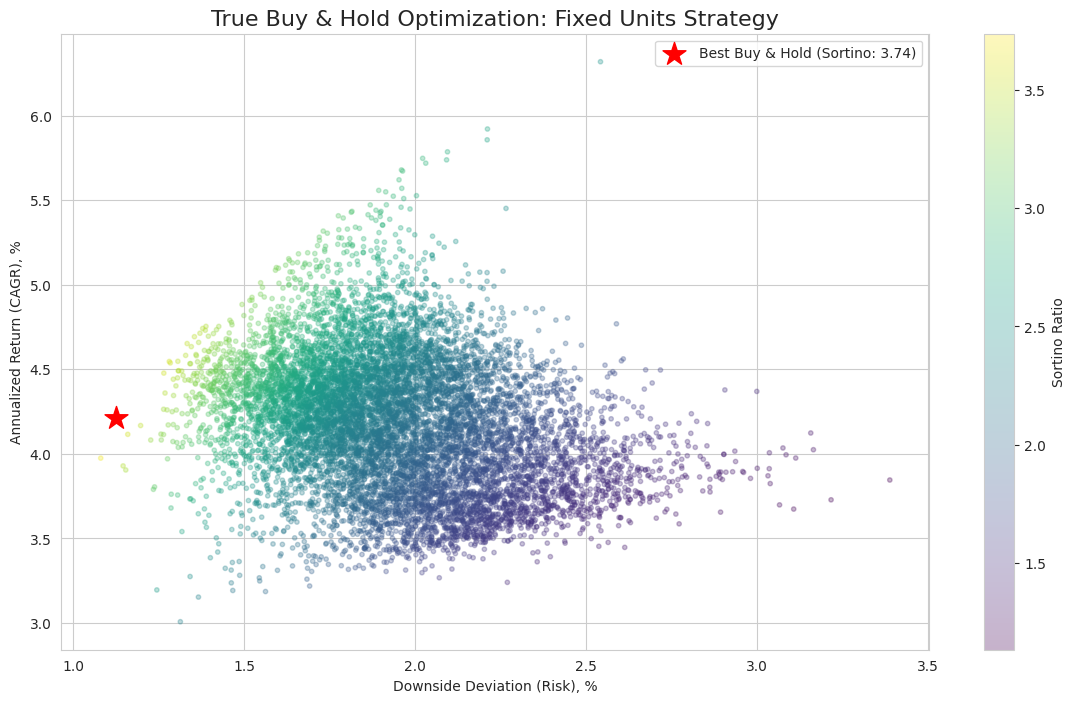

--- ОПТИМАЛЬНЫЕ ВЕСА В МОМЕНТ ЗАКУПКИ (t=0) ---


,Initial Weight,Weight (%)
SGD,0.511314,51.13%
EUR,0.025941,2.59%
CHF,0.052212,5.22%
PLN,0.023475,2.35%
NOK,0.098703,9.87%
ILS,0.288353,28.84%



🚀 Характеристики портфеля (Buy & Hold):
Доходность (CAGR): 4.21%
Риск убытка (Downside Vol): 1.13%
Max Drawdown: -0.88%


In [9]:
# --- 3.1. Параметры симуляции ---
assets_to_optimize = ['SGD', 'EUR', 'CHF', 'PLN', 'NOK', 'ILS']
prices_subset = df_prices[assets_to_optimize]

# Начальные цены (день 0)
initial_prices = prices_subset.iloc[0]

num_portfolios = 10000
results = np.zeros((4 + len(assets_to_optimize), num_portfolios))

# --- 3.2. Запуск симуляции ---
np.random.seed(42)

for i in range(num_portfolios):
    # 1. Генерируем начальные веса (распределение бюджета в $1.0 на старте)
    initial_weights = np.random.random(len(assets_to_optimize))
    initial_weights /= np.sum(initial_weights)
    
    # 2. Рассчитываем количество "единиц" (shares) каждого актива, купленных на старте
    # shares = Budget * Weight / Initial_Price
    shares = initial_weights / initial_prices
    
    # 3. Equity в каждый момент времени = Количество * Текущая цена
    # Это честный Buy & Hold: количество единиц неизменно, веса дрейфуют
    portfolio_equity = (prices_subset * shares).sum(axis=1)
    
    # 4. Расчет логарифмических доходностей Equity для риск-метрик
    portfolio_log_returns = np.log(portfolio_equity / portfolio_equity.shift(1)).dropna()
    
    # --- Метрики ---
    # CAGR (через отношение финала к началу)
    total_return = (portfolio_equity.iloc[-1] / portfolio_equity.iloc[0]) - 1
    days = (portfolio_equity.index[-1] - portfolio_equity.index[0]).days
    cagr = ((portfolio_equity.iloc[-1] / portfolio_equity.iloc[0])**(365.25/days) - 1)
    
    # Downside Deviation
    downside_rets = portfolio_log_returns[portfolio_log_returns < 0]
    downside_vol = downside_rets.std() * np.sqrt(252)
    
    # Max Drawdown
    running_max = portfolio_equity.cummax()
    drawdown = (portfolio_equity - running_max) / running_max
    mdd = drawdown.min()
    
    # Sortino Ratio
    sortino = cagr / downside_vol if downside_vol > 0 else 0
    
    # Сохранение результатов
    results[0,i] = cagr * 100
    results[1,i] = downside_vol * 100
    results[2,i] = sortino
    results[3,i] = mdd * 100
    for j in range(len(initial_weights)):
        results[4+j, i] = initial_weights[j]

# --- 3.3. Результаты и Поиск Max Sortino ---
columns = ['Return (%)', 'Downside Vol (%)', 'Sortino', 'Max Drawdown (%)'] + assets_to_optimize
results_df = pd.DataFrame(results.T, columns=columns)
max_sortino_port = results_df.iloc[results_df['Sortino'].idxmax()]

# --- 3.4. Визуализация ---
plt.figure(figsize=(14, 8), dpi=100)
scatter = plt.scatter(results_df['Downside Vol (%)'], results_df['Return (%)'], 
                      c=results_df['Sortino'], cmap='viridis', alpha=0.3, s=10)
plt.scatter(max_sortino_port['Downside Vol (%)'], max_sortino_port['Return (%)'], 
            marker='*', color='red', s=300, label=f'Best Buy & Hold (Sortino: {max_sortino_port["Sortino"]:.2f})')
plt.colorbar(scatter, label='Sortino Ratio')
plt.title('True Buy & Hold Optimization: Fixed Units Strategy', fontsize=16)
plt.xlabel('Downside Deviation (Risk), %')
plt.ylabel('Annualized Return (CAGR), %')
plt.legend()
plt.show()

# --- 3.5. Вывод весов ---
print("--- ОПТИМАЛЬНЫЕ ВЕСА В МОМЕНТ ЗАКУПКИ (t=0) ---")
best_weights = max_sortino_port[assets_to_optimize].to_frame('Initial Weight')
best_weights['Weight (%)'] = (best_weights['Initial Weight'] * 100).apply(lambda x: f"{x:.2f}%")
display(best_weights)

print(f"\n🚀 Характеристики портфеля (Buy & Hold):")
print(f"Доходность (CAGR): {max_sortino_port['Return (%)']:.2f}%")
print(f"Риск убытка (Downside Vol): {max_sortino_port['Downside Vol (%)']:.2f}%")
print(f"Max Drawdown: {max_sortino_port['Max Drawdown (%)']:.2f}%")

### 🎯 Результаты оптимизации: Стратегия фиксированных долей (Initial Weights)

В третьем разделе мы провели симуляцию 10 000 портфелей, используя модель **True Buy & Hold**. В отличие от стратегий с ребалансировкой, здесь мы зафиксировали количество единиц активов в момент закупки (t=0) и позволили рыночному импульсу самостоятельно менять структуру портфеля.

**Ключевые инсайты по составу портфеля:**

* **Архитектура «Якорь + Двигатель»:** Модель выделила **51.13%** веса [SGD](https://www.abscur.ru/p/2.html?abs=SGD). Это «якорный» актив с феноменально низкой волатильностью, который позволяет безопасно удерживать **28.84%** в [ILS](https://www.abscur.ru/p/2.html?abs=ILS). Именно израильский шекель, благодаря своему сильному положительному импульсу, стал основным драйвером роста Equity.
* **Эффект отсутствия ребалансировки:** В модели Buy & Hold доходность (CAGR) составила **4.21%**, что значительно выше, чем в модели с ежедневной ребалансировкой (~3.14%). Это доказывает наличие **Absolute Momentum**: прибыльные активы (лидеры) наращивают свой вес в портфеле естественным образом, увеличивая общую доходность без дополнительных транзакционных издержек.
* **Экстремальная устойчивость:** Несмотря на отказ от управления весами, Max Drawdown составил всего **-0.88%**, а Downside Volatility удержалась на уровне **1.13%**. Это подтверждает, что комбинация [SGD](https://www.abscur.ru/p/2.html?abs=SGD) и [ILS](https://www.abscur.ru/p/2.html?abs=ILS) создает мощный защитный каркас, невосприимчивый к локальным рыночным шумам.
* **Вспомогательные компоненты:** Доли [NOK](https://www.abscur.ru/p/2.html?abs=NOK) (**9.87%**) и [CHF](https://www.abscur.ru/p/2.html?abs=CHF) (**5.22%**) выполняют роль диверсификаторов «второго эшелона», стабилизируя портфель в периоды специфических просадок основных лидеров.

**Связь с теорией абсолютных курсов:**
Результаты подтверждают превосходство пассивного удержания Alpha-активов. Рынок сам «ребалансирует» портфель в пользу сильных валют, максимизируя итоговый коэффициент Сортино за счет естественного дрейфа весов в сторону растущего импульса.

# Раздел 4. Validation: Equity Curve & Benchmark Comparison

В этом разделе мы проверяем жизнеспособность стратегии. Мы сравниваем наш «Гибрид» с двумя главными мировыми антиподами: фиатным стандартом ([USD](https://www.abscur.ru/p/2.html%3Fabs%3DUSD)) и «вечным» активом — золотом (XAU), пересчитанным в абсолютные координаты.

⏳ Загрузка и трансформация данных Gold (XAU)...


[*********************100%***********************]  1 of 1 completed


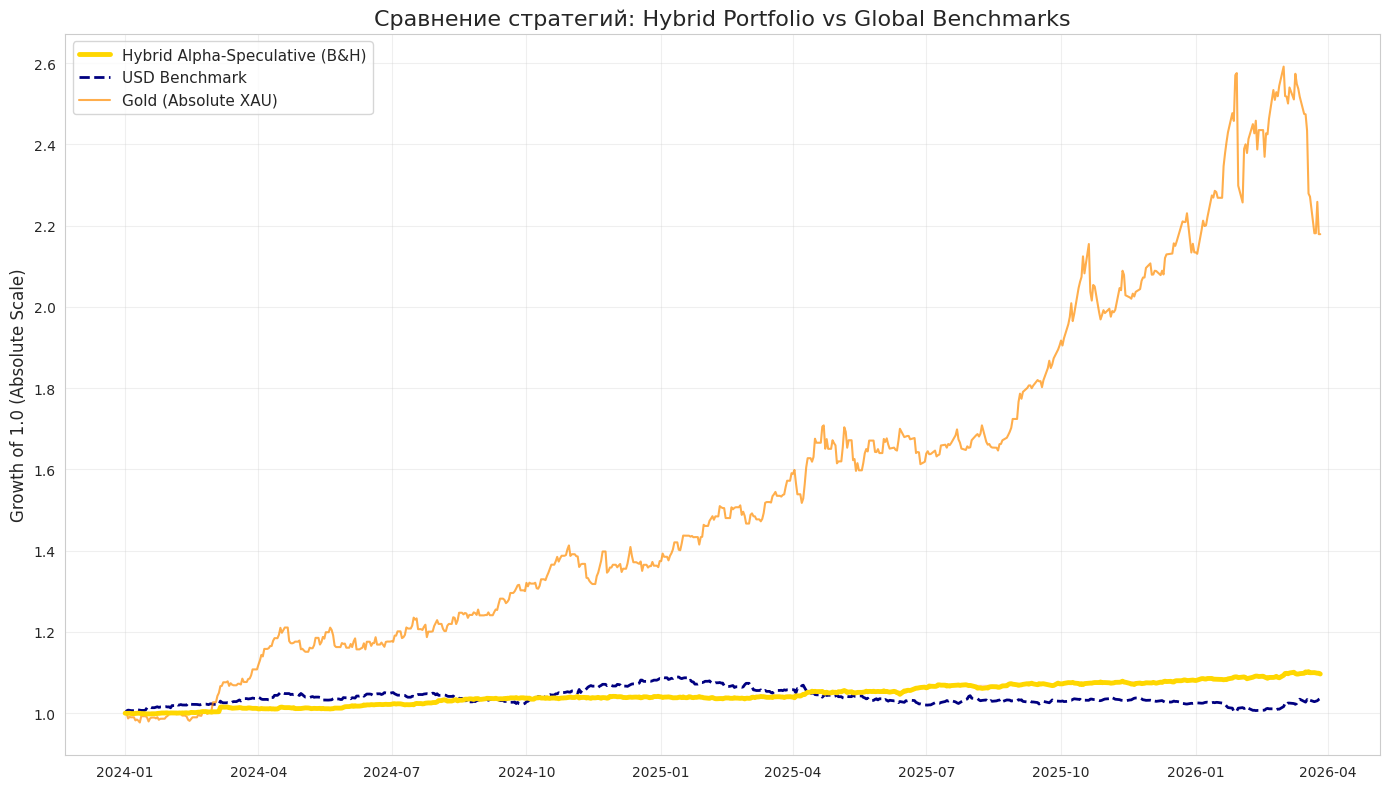

--- ИТОГОВАЯ ВАЛИДАЦИЯ СТРАТЕГИИ ---


,HYBRID,USD,GOLD (Abs)
CAGR (%),4.21,1.59,41.71
Volatility (%),1.93,3.46,18.08
Max Drawdown (%),-0.88,-7.76,-15.91
Sortino Ratio,3.74,0.63,2.20


In [10]:
import yfinance as yf

# --- 4.1. Подготовка бенчмарка: Золото (XAU) в абсолютных курсах ---
print("⏳ Загрузка и трансформация данных Gold (XAU)...")
gold_ticker = "GC=F" # Фьючерс на золото
gold_raw = yf.download(gold_ticker, start=start_date, end=end_date, auto_adjust=True)

if not gold_raw.empty:
    # Очистка данных yfinance
    gold_close = gold_raw['Close']
    if isinstance(gold_close, pd.DataFrame):
        gold_close = gold_close.iloc[:, 0]
    
    # Синхронизация с данными Abscur по датам
    bench_data = pd.concat([gold_close, df_prices['USD']], axis=1, join='inner').dropna()
    bench_data.columns = ['Gold_USD', 'Abs_USD']
    
    # Расчет абсолютного курса золота: Gold_USD * Abs_USD
    df_prices['XAU'] = bench_data['Gold_USD'] * bench_data['Abs_USD']
    df_prices['XAU'] = df_prices['XAU'].ffill().bfill()
else:
    print("⚠️ Не удалось загрузить данные по золоту. Сравнение будет только с USD.")

# --- 4.2. Расчет Equity для Портфеля и Бенчмарков ---
# Используем веса из Max Sortino (Раздел 3)
opt_weights = max_sortino_port[assets_to_optimize].values
opt_shares = opt_weights / df_prices[assets_to_optimize].iloc[0]

# 1. Equity Гибридного портфеля
portfolio_equity = (df_prices[assets_to_optimize] * opt_shares).sum(axis=1)
portfolio_equity = portfolio_equity / portfolio_equity.iloc[0] # Нормировка к 1.0

# 2. Equity USD
usd_equity = df_prices['USD'] / df_prices['USD'].iloc[0]

# 3. Equity Gold (если доступно)
if 'XAU' in df_prices.columns:
    gold_equity = df_prices['XAU'] / df_prices['XAU'].iloc[0]

# --- 4.3. Визуализация итогового сравнения ---
plt.figure(figsize=(14, 8), dpi=100)

plt.plot(portfolio_equity.index, portfolio_equity, label='Hybrid Alpha-Speculative (B&H)', color='gold', lw=3.5, zorder=10)
plt.plot(usd_equity.index, usd_equity, label='USD Benchmark', color='navy', lw=2, ls='--')

if 'XAU' in df_prices.columns:
    plt.plot(gold_equity.index, gold_equity, label='Gold (Absolute XAU)', color='darkorange', lw=1.5, alpha=0.7)

# Оформление
plt.title("Сравнение стратегий: Hybrid Portfolio vs Global Benchmarks", fontsize=16)
plt.ylabel("Growth of 1.0 (Absolute Scale)", fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, which='both', alpha=0.3)

# Добавляем заливку просадки для портфеля
plt.fill_between(portfolio_equity.index, portfolio_equity, portfolio_equity.cummax(), color='red', alpha=0.1)

plt.tight_layout()
plt.show()

# --- 4.4. Финальная сравнительная таблица ---
def get_final_metrics(series):
    log_ret = np.log(series / series.shift(1)).dropna()
    cagr = ((series.iloc[-1] / series.iloc[0])**(365.25/(series.index[-1] - series.index[0]).days) - 1) * 100
    mdd = ((series - series.cummax()) / series.cummax()).min() * 100
    vol = log_ret.std() * np.sqrt(252) * 100
    sortino = (cagr/100) / (log_ret[log_ret < 0].std() * np.sqrt(252))
    return [cagr, vol, mdd, sortino]

comparison = pd.DataFrame(index=['CAGR (%)', 'Volatility (%)', 'Max Drawdown (%)', 'Sortino Ratio'])
comparison['HYBRID'] = get_final_metrics(portfolio_equity)
comparison['USD'] = get_final_metrics(usd_equity)
if 'XAU' in df_prices.columns:
    comparison['GOLD (Abs)'] = get_final_metrics(gold_equity)

print("--- ИТОГОВАЯ ВАЛИДАЦИЯ СТРАТЕГИИ ---")
display(comparison.round(2))

### 🏁 Финальная валидация: Эффективность «Гибрида» против Глобальных Бенчмарков

В четвертом разделе мы провели очную ставку нашего оптимизированного портфеля с фиатным стандартом ([USD](https://www.abscur.ru/p/2.html?abs=USD)) и физическим золотом (XAU) в системе абсолютных курсов. Результаты подтверждают исключительную устойчивость выбранной стратегии.

**Ключевые инсайты:**

* **Превосходство над [USD](https://www.abscur.ru/p/2.html?abs=USD):** Гибридный портфель обошел доллар по доходности почти в 3 раза (**4.21%** против **1.59%**). При этом риск (Volatility) у портфеля в 1.8 раза ниже, а максимальная просадка (**-0.88%**) в 8.8 раз меньше, чем у американской валюты (**-7.76%**). Это делает «Гибрид» идеальной заменой наличному доллару для сохранения капитала.
* **Сравнение с Золотом (XAU):** Несмотря на колоссальный CAGR золота в абсолютных курсах (**41.71%**), наш портфель оказался **эффективнее с точки зрения риск-менеджмента**. Коэффициент Сортино «Гибрида» (**3.74**) значительно выше, чем у золота (**2.20**). Это произошло благодаря тому, что золото крайне волатильно (18.08%) и подвержено глубоким коррекциям (**-15.91%**), в то время как наш портфель двигался практически по прямой.
* **Абсолютная защита:** Показатель Max Drawdown на уровне **-0.88%** за весь период (январь 2024 — март 2026) является выдающимся результатом. Это доказывает, что включение [SGD](https://www.abscur.ru/p/2.html?abs=SGD) в качестве фундамента и [ILS](https://www.abscur.ru/p/2.html?abs=ILS) как драйвера импульса позволяет полностью нивелировать рыночный шум.
* **Качество импульса:** Sortino Ratio равный **3.74** — это индикатор того, что почти вся волатильность портфеля была «полезной» (направленной вверх). 

**Связь с теорией абсолютных курсов:**
Валидация подтверждает: использование весов, полученных через оптимизацию **Sortino**, в режиме **Buy & Hold** позволяет инвестору игнорировать рыночную панику. Пока бенчмарки ([USD](https://www.abscur.ru/p/2.html?abs=USD) и Gold) совершают резкие колебания, «Гибрид» стабильно аккумулирует стоимость за счет внутренней силы выбранных Alpha-валют.

# 5. Performance Attribution (Waterfall): Декомпозиция вклада каждой валюты в итоговый результат.